# Exploring position embeddings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# import gpt2 model and extract its position embeddings matrix

from transformers import GPT2Model
gpt2 = GPT2Model.from_pretrained('gpt2')
positions = gpt2.wpe.weight.detach().numpy()

In [4]:
positions.shape

(1024, 768)

# Histogram of embeddings cosine similarities

In [3]:
# cosine similarities for "time series" (token index)
Pnorm1 = positions / np.linalg.norm(positions, axis=1, keepdims=True)
cossim_tokens = Pnorm1 @ Pnorm1.T

# cosine similarities across embedding dimenrsions
Pnorm0 = positions / np.linalg.norm(positions, axis=0, keepdims=True)
cossim_embeds = Pnorm0.T @ Pnorm0

In [5]:
print(f"Shape of Pnorm1       : {Pnorm1.shape}")
print(f"Shape of cossim_tokens: {cossim_tokens.shape}")
print(f"Shape of Pnorm0       : {Pnorm0.shape}")
print(f"Shape of cossim_embeds: {cossim_embeds.shape}")

Shape of Pnorm1       : (1024, 768)
Shape of cossim_tokens: (1024, 1024)
Shape of Pnorm0       : (1024, 768)
Shape of cossim_embeds: (768, 768)


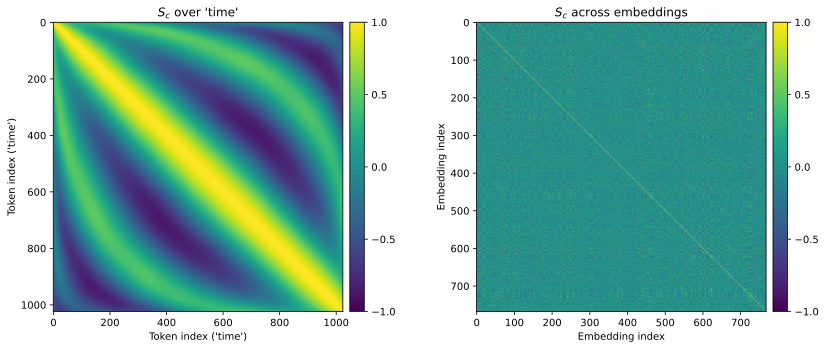

In [6]:
# draw the images
fig, axs = plt.subplots(1, 2, figsize=(12,5))

h = axs[0].imshow(cossim_tokens, vmin=-1, vmax=1)
axs[0].set(xlabel="Token index ('time')",
           ylabel="Token index ('time')",
           title="$S_c$ over 'time'")
ch = fig.colorbar(h, ax=axs[0], pad=.02, fraction=.046)
ch.ax.tick_params(labelsize=10)
ch.ax.set_yticks(np.arange(-1,1.1,.5))

h = axs[1].imshow(cossim_embeds, vmin=-1, vmax=1)
axs[1].set(xlabel="Embedding index",
           ylabel="Embedding index",
           title="$S_c$ across embeddings")
ch = fig.colorbar(h, ax=axs[1], pad=.02, fraction=.046)
ch.ax.tick_params(labelsize=10)
ch.ax.set_yticks(np.arange(-1,1.1,.5))

plt.tight_layout()
plt.show()

In [7]:
# small demo on triu:
A = np.random.randint(0, 9, (4,4))
print(A)
print('')
A[np.nonzero(np.triu(A,1))]

[[1 8 4 6]
 [2 6 8 4]
 [1 2 3 4]
 [0 2 1 5]]



array([8, 4, 6, 8, 4, 4])

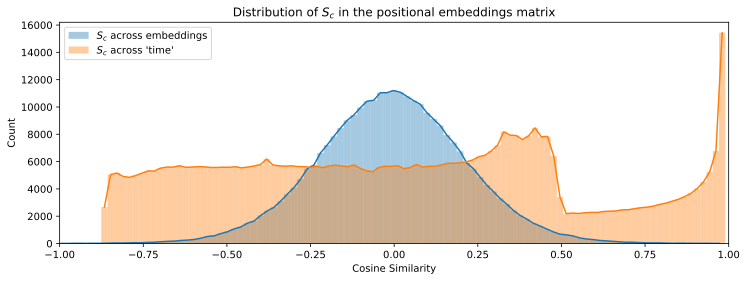

In [8]:
# get the unique cosine similarity values from the upper-triangle
unique_cs_embeds = cossim_embeds[np.nonzero(np.triu(cossim_embeds,1))] # note the ",1" to avoid the trivial diagonal
unique_cs_tokens = cossim_tokens[np.nonzero(np.triu(cossim_tokens,1))]

# get their distributions
embed_hy, embed_hx = np.histogram(unique_cs_embeds, 100)
token_hy, token_hx = np.histogram(unique_cs_tokens, 100)

# visualize
plt.figure(figsize=(12,4))
plt.bar(embed_hx[:-1], embed_hy, width=np.diff(embed_hx[:2]), alpha=.4, label="$S_c$ across embeddings")
plt.bar(token_hx[:-1], token_hy, width=np.diff(token_hx[:2]), alpha=.4, label="$S_c$ across 'time'")
plt.plot(embed_hx[:-1], embed_hy)
plt.plot(token_hx[:-1], token_hy)

plt.legend()
plt.gca().set(xlim=[-1,1],
              xlabel="Cosine Similarity",
              ylabel="Count",
              title="Distribution of $S_c$ in the positional embeddings matrix")
plt.show()

# create a shuffled cosine similarity distribution

In [9]:
# vectorize and copy the positions
random_embeds = positions.flatten()

# randomly shuffle them
np.random.shuffle(random_embeds)

# reshape back to the matrix
random_embeds = random_embeds.reshape(positions.shape)

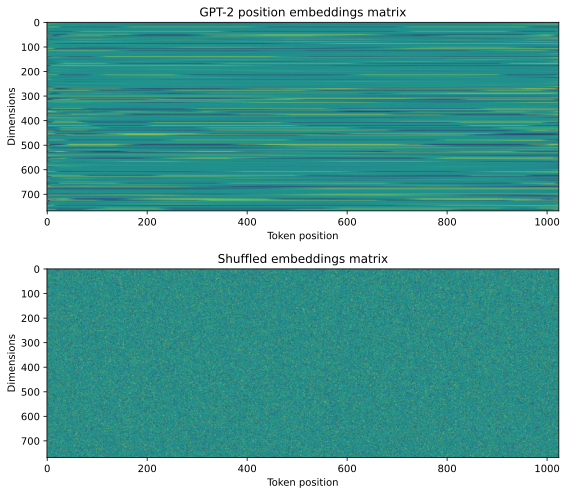

In [10]:
_,axs = plt.subplots(2,1,figsize=(8,7))

axs[0].imshow(positions.T,aspect='auto',vmin=-.1,vmax=.1)
axs[0].set(xlabel='Token position',ylabel='Dimensions',title='GPT-2 position embeddings matrix')

axs[1].imshow(random_embeds.T,aspect='auto',vmin=-.1,vmax=.1)
axs[1].set(xlabel='Token position',ylabel='Dimensions',title='Shuffled embeddings matrix')


plt.tight_layout()
plt.show()

In [11]:
# calculate cosine similarity
Rnorm0 = random_embeds / np.linalg.norm(random_embeds, axis=0, keepdims=True)
cossim_random = Rnorm0.T @ Rnorm0

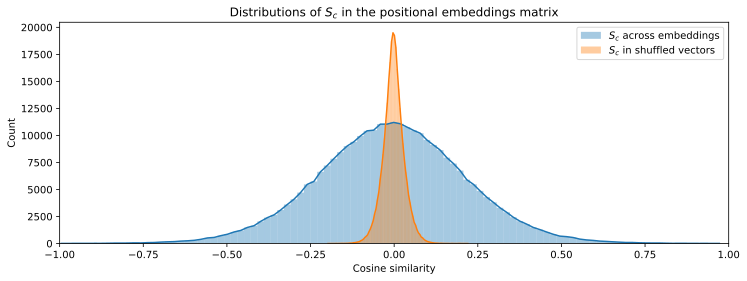

In [12]:
# get the unique cosine similarity values from the upper-triangle
unique_cs_random = cossim_random[np.nonzero(np.triu(cossim_random,1))]

# get their distribution
random_hy, random_hx = np.histogram(unique_cs_random, 100)

# visualize!
plt.figure(figsize=(12,4))
plt.bar(embed_hx[:-1],embed_hy,width=np.diff(embed_hx[:2]),alpha=.4,label='$S_c$ across embeddings')
plt.bar(random_hx[:-1],random_hy,width=np.diff(random_hx[:2]),alpha=.4,label='$S_c$ in shuffled vectors')
plt.plot(embed_hx[:-1],embed_hy)
plt.plot(random_hx[:-1],random_hy)

plt.legend()
plt.gca().set(xlim=[-1,1],
              xlabel='Cosine similarity',
              ylabel='Count',
              title='Distributions of $S_c$ in the positional embeddings matrix')
plt.show()

# Find similar pairs

Cossim of 0.992 in pair (356,528)
Cossim of 0.943 in pair (320,540)
Cossim of 0.915 in pair (308,528)
Cossim of 0.885 in pair (107,271)
Cossim of 0.864 in pair (365,525)
Cossim of 0.845 in pair (479,623)
Cossim of 0.829 in pair (49,724)
Cossim of 0.813 in pair (71,365)
Cossim of 0.800 in pair (167,439)
Cossim of 0.794 in pair (527,623)


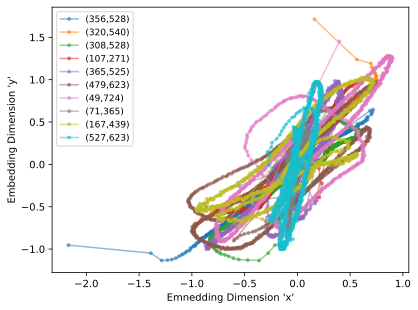

In [13]:
# reminder: positions matrix is size [index,embedding]

sortidx = np.argsort(np.triu(cossim_embeds,1).flatten())[::-1]
xx, yy = np.unravel_index(sortidx, cossim_embeds.shape)

for i in np.linspace(0, 200, 10).astype(int):
    # get and print the pairs
    pairname = f'({xx[i]},{yy[i]})'
    print(f'Cossim of {cossim_embeds[xx[i],yy[i]]:.3f} in pair {pairname}')

    # plot them
    plt.plot(positions[:,xx[i]], positions[:,yy[i]], '.-', alpha=.5, label=pairname)

# adjustments
plt.gca().set(xlabel="Emnedding Dimension 'x'",
              ylabel="Embedding Dimension 'y'")
plt.legend(fontsize=9)
plt.show()